In [1]:
import pandas as pd                 
import matplotlib.pyplot as plt      
import seaborn as sns                

# On charge le fichier CSV téléchargé sur Kaggle
df = pd.read_csv("netflix_titles.csv")

# On regarde ce qu'on a
print("Taille du dataset :", df.shape)

df.head(3)    #les 3 premiers lignes

Taille du dataset : (6234, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."


In [2]:
#Nettoyage des données

print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

df = df.dropna(subset=["country", "date_added"])

print("Lignes restantes après nettoyage :", len(df))

# On la convertit en vrai format date, puis on extrait l'année

df["year_added"] = pd.to_datetime(
    df["date_added"].str.strip()  
).dt.year                          

print("\nAnnées disponibles :", sorted(df["year_added"].unique()))

df["duration_value"] = (
    df["duration"]
    .str.extract(r"(\d+)")  
    .astype(float)           
)

# Vérification
print("\nExemple de durées :")
print(df[["type", "duration", "duration_value"]].head(5))


df["main_country"] = (
    df["country"]
    .str.split(",")   
    .str[0]            
    .str.strip()       
)

print("\nDataset prêt !")
print("Taille finale :", df.shape)

Valeurs manquantes par colonne :
show_id            0
type               0
title              0
director        1969
cast             570
country          476
date_added        11
release_year       0
rating            10
duration           0
listed_in          0
description        0
dtype: int64
Lignes restantes après nettoyage : 5749

Années disponibles : [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]

Exemple de durées :
      type  duration  duration_value
0    Movie    90 min            90.0
1    Movie    94 min            94.0
2  TV Show  1 Season             1.0
3  TV Show  1 Season             1.0
4    Movie    99 min            99.0

Dataset prêt !
Taille finale : (5749, 15)


    year_added  nombre_de_titres
0         2008                 2
1         2009                 2
2         2010                 1
3         2011                13
4         2012                 6
5         2013                12
6         2014                25
7         2015                86
8         2016               440
9         2017              1224
10        2018              1642
11        2019              2130
12        2020               166


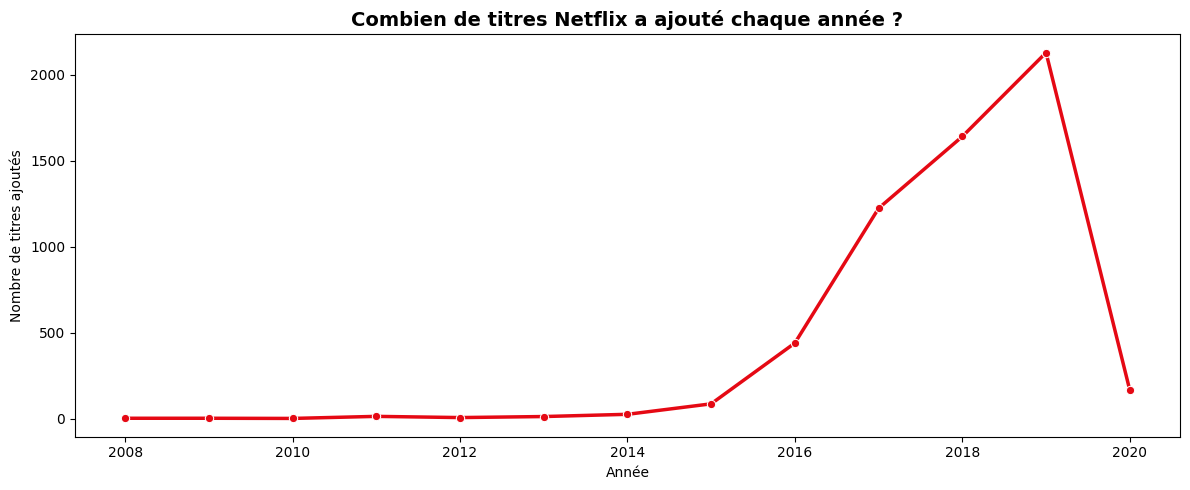

In [3]:
#analyse par année
# On compte combien de titres ont été ajoutés chaque année
ajouts_par_annee = (
    df
    .groupby("year_added")  
    .size()                  
    .reset_index(name="nombre_de_titres") 
)

print(ajouts_par_annee)

# Graphique

plt.figure(figsize=(12, 5))  

sns.lineplot(
    data=ajouts_par_annee,
    x="year_added",
    y="nombre_de_titres",
    marker="o",          
    color="#E50914",    
    linewidth=2.5
)
plt.title("Combien de titres Netflix a ajouté chaque année ?",
          fontsize=14, fontweight="bold")
plt.xlabel("Année")
plt.ylabel("Nombre de titres ajoutés")

plt.tight_layout()                             
plt.savefig("ajouts_par_annee.png", dpi=150)   
plt.show()

             pays  nombre
0   United States    2296
1           India     808
2  United Kingdom     482
3          Canada     206
4           Japan     183
5          France     147
6     South Korea     146
7           Spain     139
8          Mexico      99
9       Australia      93


C:\Users\maath\AppData\Local\Temp\ipykernel_5132\4153058402.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


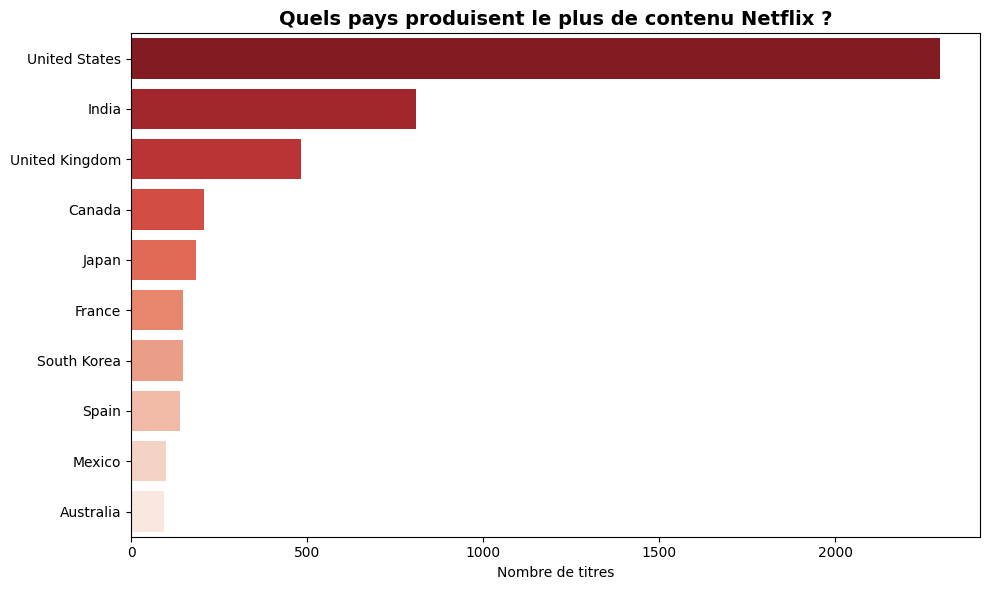

In [4]:
#Analyse par pays
# On compte le nombre de titres par pays
top_10_pays = (
    df["main_country"]
    .value_counts()       
    .head(10)             
    .reset_index()       
)
top_10_pays.columns = ["pays", "nombre"]

print(top_10_pays)

# Graphique

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_pays,
    x="nombre",   
    y="pays",   
    palette="Reds_r"  
)

plt.title("Quels pays produisent le plus de contenu Netflix ?",
          fontsize=14, fontweight="bold")
plt.xlabel("Nombre de titres")
plt.ylabel("")  

plt.tight_layout()
plt.savefig("top_pays.png", dpi=150)
plt.show()

type
Movie      4070
TV Show    1679
Name: count, dtype: int64


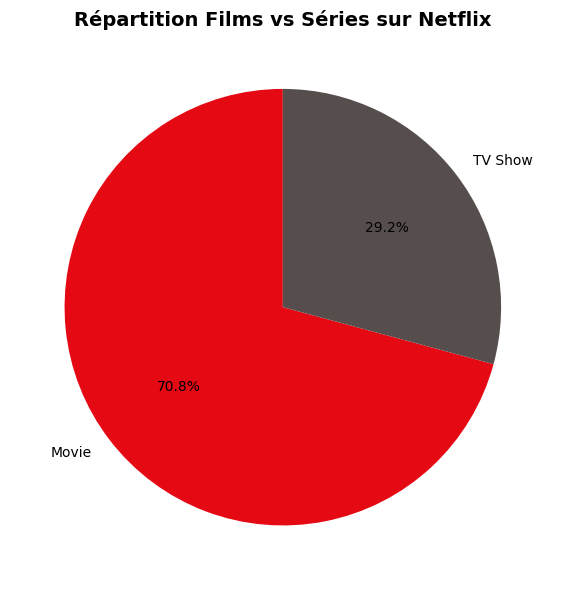

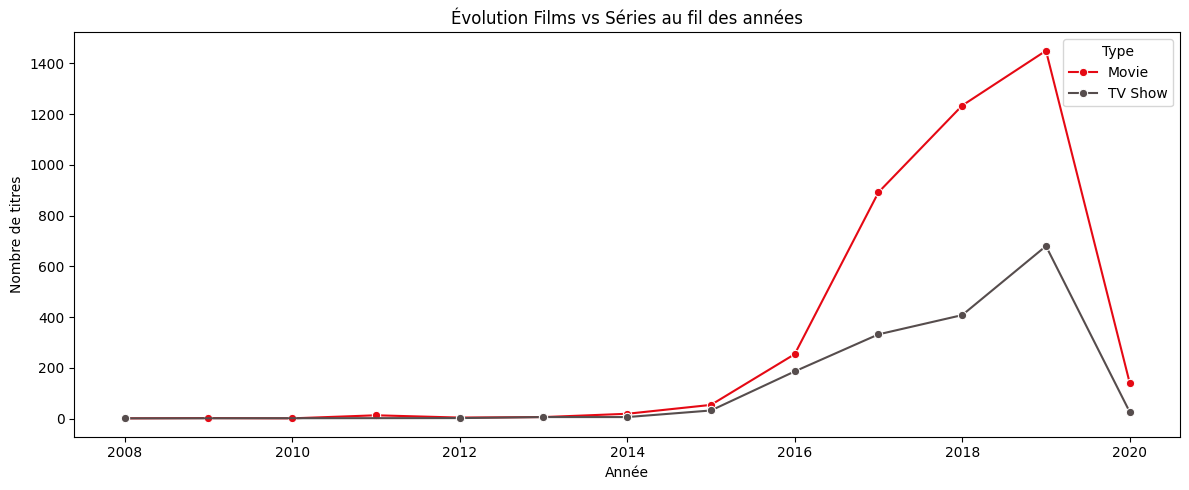

In [5]:
# On compte combien de films et de séries il y a
repartition = df["type"].value_counts()

print(repartition)
# Movie      5550  → 69.6%
# TV Show    2419  → 30.4%

# Graphique camembert

plt.figure(figsize=(6, 6))

plt.pie(
    repartition.values,          
    labels=repartition.index,    
    autopct="%1.1f%%",           
    colors=["#E50914", "#564D4D"],  
    startangle=90               
)

plt.title("Répartition Films vs Séries sur Netflix",
          fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("films_vs_series.png", dpi=150)
plt.show()


# Évolution dans le temps

# On compte par année ET par type
evolution_type = (
    df
    .groupby(["year_added", "type"])
    .size()
    .reset_index(name="nombre")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=evolution_type,
    x="year_added",
    y="nombre",
    hue="type",      # une couleur par type
    marker="o",
    palette={"Movie": "#E50914", "TV Show": "#564D4D"}
)

plt.title("Évolution Films vs Séries au fil des années")
plt.xlabel("Année")
plt.ylabel("Nombre de titres")
plt.legend(title="Type")

plt.tight_layout()
plt.savefig("evolution_type.png", dpi=150)
plt.show()

Durée moyenne d'un film  : 100 minutes
Durée médiane d'un film  : 98 minutes
Nombre de saisons moyen  : 1.9 saisons


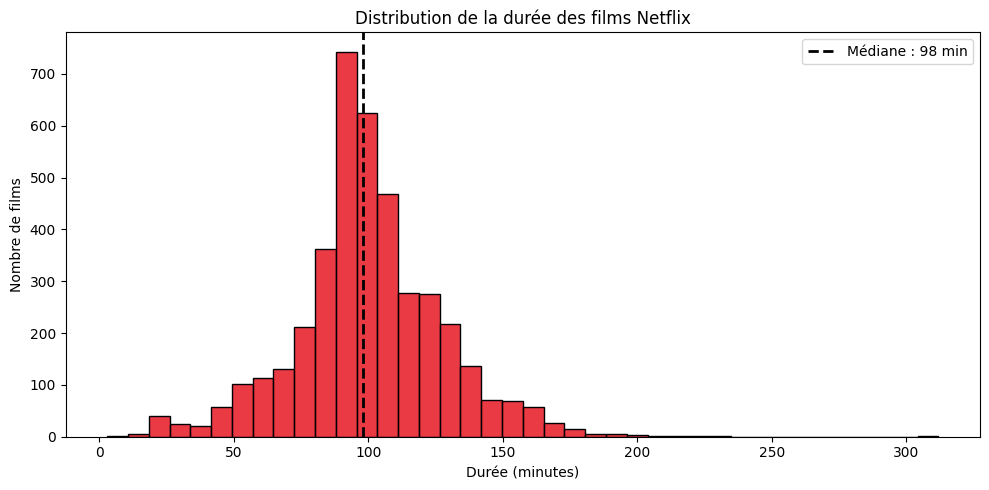

In [6]:
# On sépare les films et les séries
# Films → minutes / Séries → nombre de saisons

films  = df[df["type"] == "Movie"]
series = df[df["type"] == "TV Show"]

# Calcul des moyennes
duree_moyenne_film   = films["duration_value"].mean()
duree_mediane_film   = films["duration_value"].median()
saisons_moyennes     = series["duration_value"].mean()

print(f"Durée moyenne d'un film  : {duree_moyenne_film:.0f} minutes")
print(f"Durée médiane d'un film  : {duree_mediane_film:.0f} minutes")
print(f"Nombre de saisons moyen  : {saisons_moyennes:.1f} saisons")

#Distribution des durées

plt.figure(figsize=(10, 5))

sns.histplot(
    films["duration_value"].dropna(),  
    bins=40,           
    color="#E50914",
    alpha=0.8         
)

# Ligne verticale pour la moyenne
plt.axvline(
    x=duree_mediane_film,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Médiane : {duree_mediane_film:.0f} min"
)

plt.title("Distribution de la durée des films Netflix")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")
plt.legend()

plt.tight_layout()
plt.savefig("duree_films.png", dpi=150)
plt.show()

Top 5 genres :
                    genre  nombre
0    International Movies    1859
1                  Dramas    1590
2                Comedies    1077
3  International TV Shows     818
4           Documentaries     615


C:\Users\maath\AppData\Local\Temp\ipykernel_5132\1092375317.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


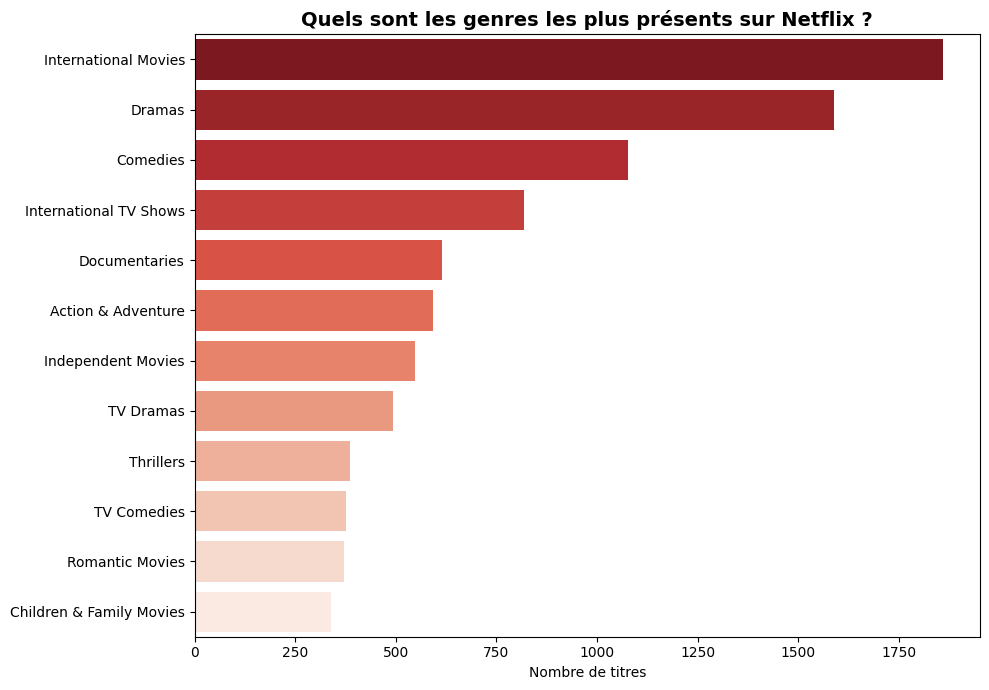

In [7]:
#genre dominant

genres = (
    df["listed_in"]
    .str.split(", ")   
    .explode()          
    .value_counts()     
    .head(12)           
    .reset_index()
)
genres.columns = ["genre", "nombre"]

print("Top 5 genres :")
print(genres.head(5))

# Graphique

plt.figure(figsize=(10, 7))

sns.barplot(
    data=genres,
    x="nombre",
    y="genre",
    palette="Reds_r"
)

plt.title("Quels sont les genres les plus présents sur Netflix ?",
          fontsize=14, fontweight="bold")
plt.xlabel("Nombre de titres")
plt.ylabel("")

plt.tight_layout()
plt.savefig("genres.png", dpi=150)
plt.show()

C:\Users\maath\AppData\Local\Temp\ipykernel_5132\1262727067.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maath\AppData\Local\Temp\ipykernel_5132\1262727067.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


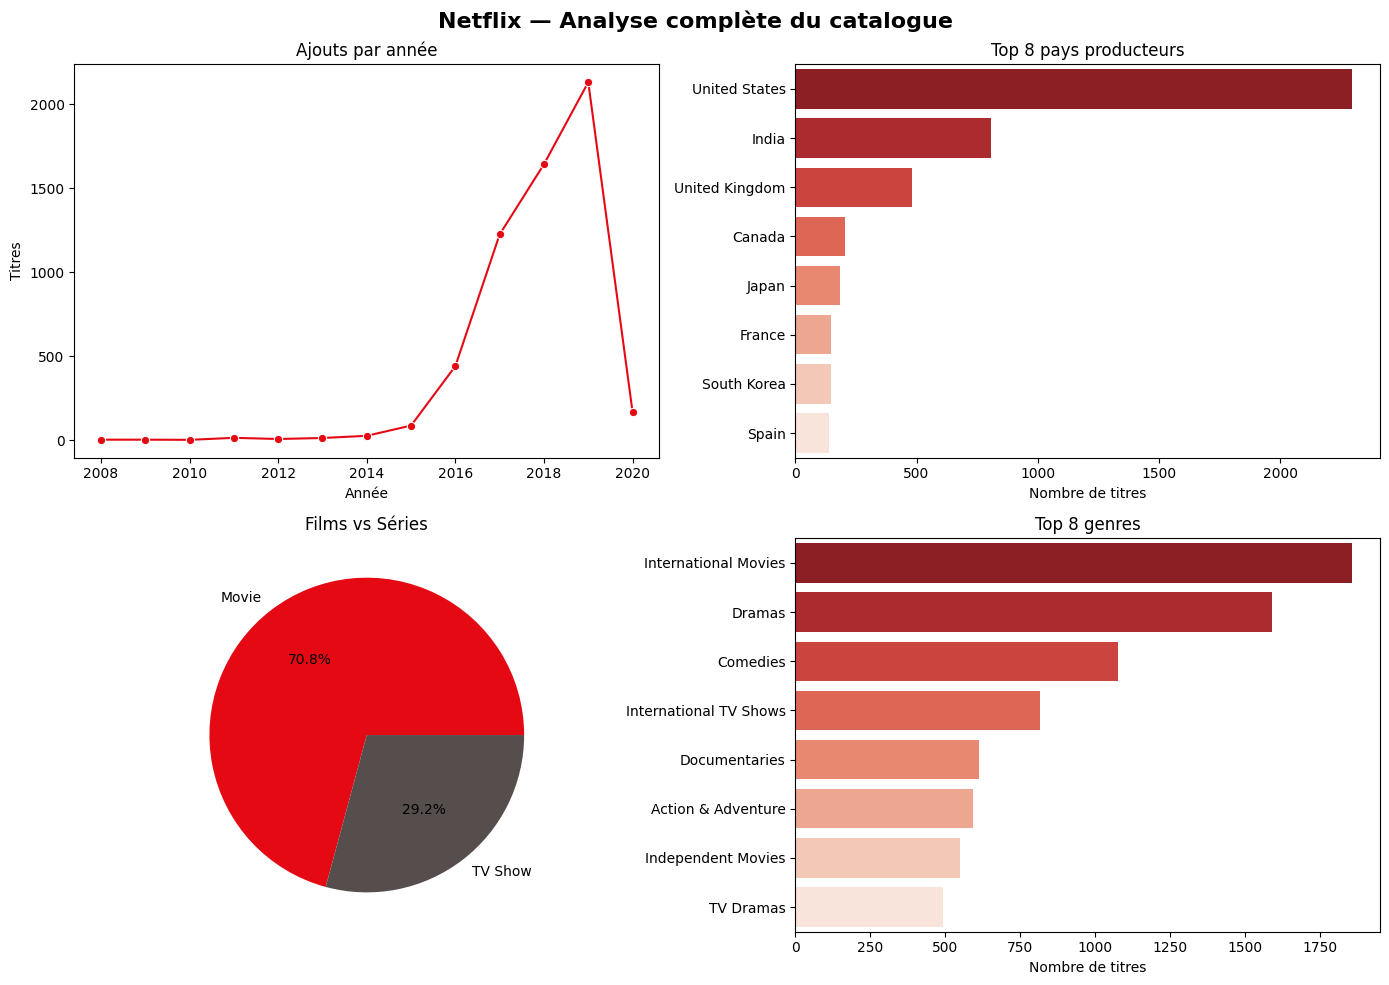

Dashboard sauvegardé !


In [8]:
#Les graphiques
fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 10)
)

fig.suptitle(
    "Netflix — Analyse complète du catalogue",
    fontsize=16, fontweight="bold"
)

# Graphique ajout années
sns.lineplot(
    data=ajouts_par_annee,
    x="year_added", y="nombre_de_titres",
    ax=axes[0, 0],          
    color="#E50914", marker="o"
)
axes[0, 0].set_title("Ajouts par année")
axes[0, 0].set_xlabel("Année")
axes[0, 0].set_ylabel("Titres")

# Graphique top pays
sns.barplot(
    data=top_10_pays.head(8),
    x="nombre", y="pays",
    ax=axes[0, 1],
    palette="Reds_r"
)
axes[0, 1].set_title("Top 8 pays producteurs")
axes[0, 1].set_xlabel("Nombre de titres")
axes[0, 1].set_ylabel("")

#Graphique films vs series
axes[1, 0].pie(
    repartition.values,
    labels=repartition.index,
    autopct="%1.1f%%",
    colors=["#E50914", "#564D4D"]
)
axes[1, 0].set_title("Films vs Séries")

# Graphiques top genre
sns.barplot(
    data=genres.head(8),
    x="nombre", y="genre",
    ax=axes[1, 1],
    palette="Reds_r"
)
axes[1, 1].set_title("Top 8 genres")
axes[1, 1].set_xlabel("Nombre de titres")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.savefig("dashboard_netflix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Dashboard sauvegardé !")

In [10]:
# Insights business

print("=" * 45)
print("   INSIGHTS — ANALYSE NETFLIX")
print("=" * 45)

print(f"\n Dataset")
print(f"   Titres analysés   : {len(df)}")
print(f"   Pays représentés  : {df['main_country'].nunique()}")

print(f"\n Type de contenu")
films_pct = repartition["Movie"] / len(df) * 100
print(f"   Films             : {films_pct:.1f}%")
print(f"   Séries            : {100 - films_pct:.1f}%")

print(f"\n Durée")
print(f"   Médiane film      : {duree_mediane_film:.0f} min")
print(f"   Saisons (moy.)    : {saisons_moyennes:.1f}")

print(f"\n Top résultats")
print(f"   Pays n°1          : {top_10_pays.iloc[0]['pays']}")
print(f"   Genre n°1         : {genres.iloc[0]['genre']}")
annee_pic = ajouts_par_annee.loc[
    ajouts_par_annee["nombre_de_titres"].idxmax(),
    "year_added"
]
print(f"   Pic d'ajouts      : {int(annee_pic)}")

print("\n" + "=" * 45)
print("   Analyse terminée ✓")
print("=" * 45)

   INSIGHTS — ANALYSE NETFLIX

 Dataset
   Titres analysés   : 5749
   Pays représentés  : 72

 Type de contenu
   Films             : 70.8%
   Séries            : 29.2%

 Durée
   Médiane film      : 98 min
   Saisons (moy.)    : 1.9

 Top résultats
   Pays n°1          : United States
   Genre n°1         : International Movies
   Pic d'ajouts      : 2019

   Analyse terminée ✓
